In [207]:
# read before implementing: http://scikit-survival.readthedocs.io/en/stable/user_guide/coxnet.html

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings

from sklearn.model_selection import GridSearchCV, KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.exceptions import FitFailedWarning

from sksurv.linear_model import CoxnetSurvivalAnalysis, CoxPHSurvivalAnalysis
from sksurv.util import Surv

# Preparing Data

In [208]:
# load in datasets
df = pd.read_csv('../datasets/csv_files/univariate_cox_sig_train.csv')
expr = pd.read_csv('../datasets/csv_files/filtered_expression_matrix_train.csv')
clinical = pd.read_csv('../datasets/csv_files/clinical_metadata_train.csv')
clinical.head()

,sample_name,tissue_type,patient_age,tumor_grade,tumor_size,er_status,lymph_node_status,relapse_free_event,relapse_free_time,overall_survival_event,overall_survival_time
0,GSM1045191,normal breast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GSM1045192,normal breast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GSM1045193,normal breast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,GSM1045194,normal breast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,GSM1045195,normal breast,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [209]:
# make a list of all sig genes
sig_genes = list(df['gene'])

def filter_expr_matrix(sig_genes):
    columns_to_keep = ['sample_name'] + sig_genes
    expr_filtered = expr[columns_to_keep]
    return expr_filtered

expr_filtered = filter_expr_matrix(sig_genes)
expr_filtered.head()

,sample_name,FBXL5,EVL,POLR3GL,CDC20,KLHL5,GATA3,BLNK,SOX4,RARRES3,UBE2S,SOX11,HSPA2,ERAP1,HEBP2,S100P,DEFB132,COLEC12,MICB,EIF4E3,SFRP1,COL1A2,GNS,BIRC5,PREX1,JAM2,FLNB,FBN1,ARF1,UBE2E3,FBXL16,CFB,UBE2C,SOD2,C6orf120,TRIM45,GPAM,CXCL14,MTHFD1,CEBPA,SPHK1,MDK,CEBPD,VAV3,STAT5A,ACO1,TF,DCTN6,MYB,ALDOC,PRLR,S100B,CXCL12,FOS,CLU,DENND1B
0,GSM1045191,9.349612,6.706219,8.934395,4.115221,6.072575,7.856321,5.236619,6.020647,6.691742,4.445544,3.610599,6.811801,6.073895,8.657532,5.073908,8.357489,7.386655,5.413113,6.647043,8.212325,9.724916,8.152319,5.020987,6.427861,6.737205,7.674695,9.443282,6.092818,8.086589,4.139581,5.875372,5.762288,9.288465,7.873989,4.930487,11.131842,9.003476,9.063218,9.301750,5.240195,5.188450,8.235638,4.577871,7.981321,6.697765,6.901910,8.011800,4.076484,8.414169,4.169347,5.882043,8.692766,9.241674,8.872059,4.535944
1,GSM1045192,6.924984,6.902763,7.695524,4.983372,4.181562,4.400473,5.595045,6.048561,6.078527,4.422642,3.957840,3.751913,4.870039,6.820609,4.521399,3.296474,6.404261,6.659727,4.446082,4.122025,11.920659,7.004034,5.306103,5.820572,4.511988,7.232041,6.632032,5.646816,7.631840,4.614759,5.743448,6.562398,8.606902,5.558054,4.745991,5.648319,7.550896,6.632947,7.390315,7.517480,6.270123,6.229825,4.369697,7.601242,5.872591,4.818204,6.945578,3.479348,4.581926,3.922638,3.890485,8.331071,6.043630,4.680555,4.496711
2,GSM1045193,6.849612,6.924813,7.523264,7.253961,5.337126,4.790456,8.674915,4.799969,5.905687,4.878597,4.013856,4.414112,4.140759,5.853338,4.638771,2.953570,4.816429,6.921534,4.109932,3.740194,5.296262,4.267152,5.840283,5.631678,4.245401,5.897476,4.505984,5.753160,5.918055,4.833464,5.258735,8.131192,4.838683,4.904271,5.288228,4.731407,5.818348,5.941661,5.967707,5.006029,5.771265,4.134739,4.458827,7.501134,4.704279,4.746406,5.743512,4.209691,6.235045,3.890817,3.042820,5.125342,3.225278,7.395010,4.766417
3,GSM1045194,6.887577,7.539193,6.981070,5.081718,4.675391,8.047584,4.519967,7.113616,7.085160,4.498002,4.217862,6.885950,4.674292,7.422224,5.977879,3.292748,4.931116,5.217874,4.598521,6.668952,7.540045,5.922380,4.655123,6.952114,5.580741,8.230931,5.414084,6.109073,6.636934,4.935647,5.351327,6.678973,9.178988,4.857066,5.912944,5.067370,6.977624,6.383969,6.003971,5.553088,6.423919,7.220704,5.733220,7.285756,4.650540,4.738504,7.312495,5.487642,6.079837,4.683971,3.582345,6.979433,5.267140,6.827116,3.885857
4,GSM1045195,9.268375,6.278225,8.821340,4.404020,6.000885,6.211413,4.955369,5.754098,6.443146,4.847608,3.618940,5.802109,6.349878,8.598673,4.839788,6.843711,8.182421,5.132874,6.837103,8.181754,9.776909,7.981259,4.104090,6.107303,7.497917,6.856871,9.196846,5.287706,8.291460,3.937953,5.574557,5.305743,10.132265,8.215887,4.677008,11.344489,8.911049,9.651571,10.317095,5.639049,5.001135,7.528966,4.054034,8.350870,8.647494,7.463235,8.343800,3.289744,8.294877,3.516181,5.930763,9.229506,10.637220,8.478074,4.249614


In [210]:
# prepare train data
clinical_columns = ['sample_name', 'relapse_free_event', 'relapse_free_time']

train_data = pd.merge(
    clinical[clinical_columns],
    expr_filtered[:],
    on='sample_name'
)

train_data = train_data.dropna()
train_data[['relapse_free_event', 'relapse_free_time']] = train_data[['relapse_free_event', 'relapse_free_time']].astype(int)

train_data.head()

,sample_name,relapse_free_event,relapse_free_time,FBXL5,EVL,POLR3GL,CDC20,KLHL5,GATA3,BLNK,SOX4,RARRES3,UBE2S,SOX11,HSPA2,ERAP1,HEBP2,S100P,DEFB132,COLEC12,MICB,EIF4E3,SFRP1,COL1A2,GNS,BIRC5,PREX1,JAM2,FLNB,FBN1,ARF1,UBE2E3,FBXL16,CFB,UBE2C,SOD2,C6orf120,TRIM45,GPAM,CXCL14,MTHFD1,CEBPA,SPHK1,MDK,CEBPD,VAV3,STAT5A,ACO1,TF,DCTN6,MYB,ALDOC,PRLR,S100B,CXCL12,FOS,CLU,DENND1B
17,GSM1045208,0,3026,7.780658,9.176116,7.009545,6.583813,4.727495,11.243921,8.036585,7.735311,7.497585,4.844556,3.760450,8.801399,4.911956,6.848206,10.187309,3.001555,7.359875,5.753997,5.991336,5.957335,10.739465,6.423502,5.195550,7.073281,5.179025,8.759435,6.246257,6.901615,5.809944,5.220802,7.205254,8.458957,6.141279,6.647842,6.428617,5.877630,11.798407,7.813484,6.304646,6.118828,6.349483,5.476177,5.647802,7.169852,4.799942,4.314603,5.922452,5.503582,5.383726,5.409960,2.802160,7.329267,4.866050,6.878972,5.150305
18,GSM1045209,1,755,7.242231,7.921031,6.696948,8.425245,4.202276,10.374649,6.248417,7.967062,5.361069,6.627002,4.592975,5.951025,4.684796,7.303930,6.677150,3.119509,5.794930,5.143781,3.975456,4.891883,12.043543,6.511267,6.238223,9.047317,5.521038,8.171253,7.478497,6.977265,5.596044,5.929740,7.136334,9.120323,5.582510,5.663028,6.394637,5.925626,6.697138,7.254114,7.265529,7.036110,7.848696,6.687999,4.995820,6.309295,4.971609,4.921310,6.672498,5.670921,5.854996,5.118496,3.144127,7.558426,6.014123,7.780951,5.222316
19,GSM1045210,0,3014,7.540444,8.894975,6.311942,7.338158,4.771116,10.954085,7.606303,8.076291,7.457848,4.907463,3.971771,8.515325,4.873513,6.909069,10.623973,2.982960,7.039614,6.212378,5.541002,6.066592,10.731082,6.234312,5.261777,6.829690,5.344655,8.512763,6.453394,6.582153,5.575941,5.401792,7.301934,8.347129,6.262349,6.634463,6.074443,5.493570,11.618586,7.482227,6.570841,6.025137,7.003300,6.107935,5.194826,6.531898,4.555494,4.437907,5.868416,5.181722,5.317867,5.396281,2.819787,7.058830,3.910671,7.028702,4.926403
20,GSM1045211,1,406,6.171535,8.815157,6.221754,7.468727,3.711394,9.546771,5.238047,7.511513,5.947950,5.012260,4.995021,7.107150,4.686461,6.234049,11.189967,2.820621,6.681315,6.985434,4.008162,5.481523,12.341981,6.074219,6.726608,7.002943,4.464965,7.893826,7.290744,6.838820,5.128132,5.254027,5.207979,8.142920,5.432534,5.798999,5.916733,4.570552,9.092684,6.905146,6.126487,7.682202,6.749071,5.820589,5.039221,6.227280,4.668031,4.252302,5.885133,4.632032,6.408760,4.227421,3.107371,7.541663,6.202788,5.895270,4.022105
21,GSM1045212,0,2225,7.167023,6.811868,7.567759,9.645149,4.633546,8.410182,6.438748,7.601258,9.188105,7.380517,5.489588,6.878727,4.891033,7.760441,10.322314,2.851260,6.241178,8.199680,4.846990,7.311862,11.140902,6.802662,7.265202,6.628687,4.865721,9.472533,6.887684,6.733200,8.221396,4.999650,6.896423,9.205154,6.716884,5.556022,6.681431,4.482931,5.977753,8.217102,6.761938,8.407370,8.426718,6.264166,5.193608,7.649678,5.458046,4.873803,5.957434,3.345111,8.048325,4.102159,3.240011,7.788142,8.218544,6.810512,4.499718


In [211]:
# prepare x & y
x = train_data.drop(columns=['sample_name', 'relapse_free_event', 'relapse_free_time'])
y = Surv.from_dataframe('relapse_free_event', 'relapse_free_time', train_data)

In [212]:
def plot_coefficients(coefs, n_highlight):
    fig, ax = plt.subplots(figsize=(9, 6))
    alphas = coefs.columns
    for row in coefs.itertuples():
        ax.semilogx(alphas, row[1:], ".-", label=row.Index)

    alpha_min = alphas.min()
    top_coefs = coefs.loc[:, alpha_min].map(abs).sort_values().tail(n_highlight)
    for name in top_coefs.index:
        coef = coefs.loc[name, alpha_min]
        plt.text(alpha_min, coef, name + "   ", horizontalalignment="right", verticalalignment="center")

    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()
    ax.grid(True)
    ax.set_xlabel("alpha")
    ax.set_ylabel("coefficient")

# LASSO

In [213]:
def lasso_cox(x, y):
    cox_lasso = CoxnetSurvivalAnalysis(l1_ratio=1.0, alpha_min_ratio=0.01)
    cox_lasso.fit(x, y)

    return pd.DataFrame(cox_lasso.coef_, index=x.columns, columns=np.round(cox_lasso.alphas_, 5))

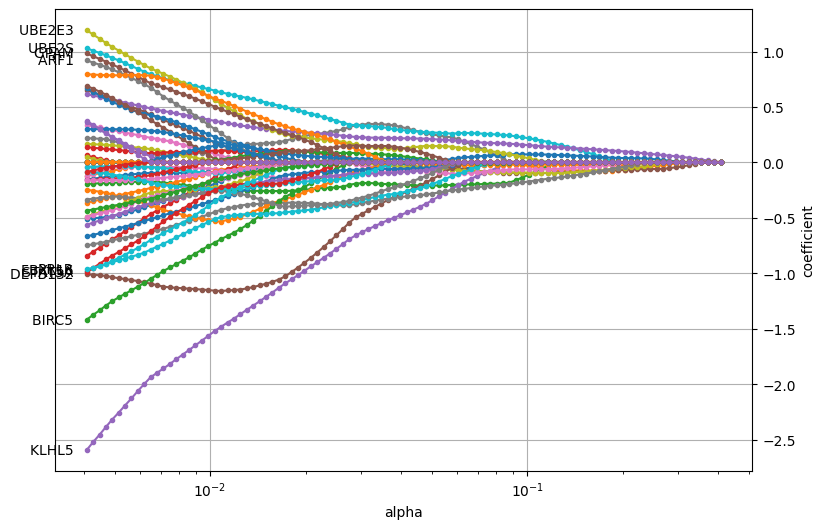

In [214]:
coeff_lasso = lasso_cox(x, y)
plot_coefficients(coeff_lasso, 10)

# Elastic Net

In [215]:
def elastic_net_cox(x, y):
    cox_elastic_net = CoxnetSurvivalAnalysis(l1_ratio=0.9, alpha_min_ratio=0.01)
    cox_elastic_net.fit(x, y)

    return pd.DataFrame(
        cox_elastic_net.coef_, index=x.columns, columns=np.round(cox_elastic_net.alphas_, 5)
    )

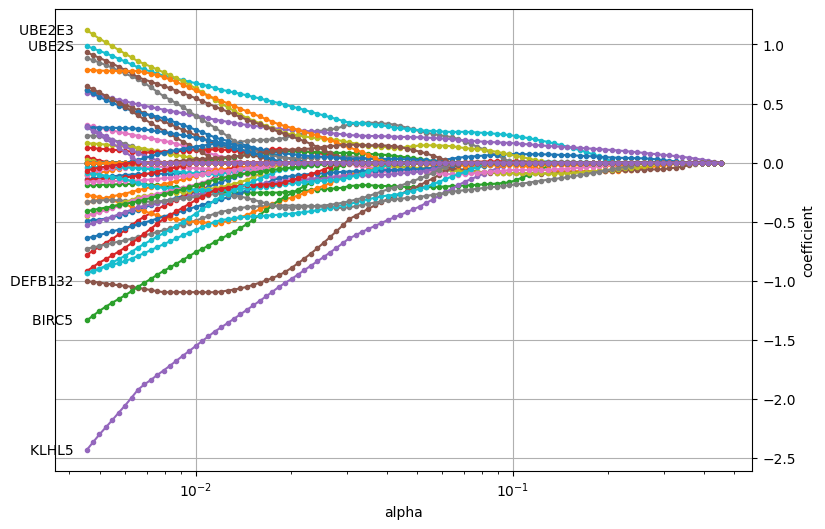

In [216]:
coeff_elastic_net = elastic_net_cox(x, y)
plot_coefficients(coeff_elastic_net, 5)

# Choose Alpha Strength

In [217]:
def get_alpha_max_min(x, y, l1_ratio=1.0):
    coxnet_pipe = make_pipeline(StandardScaler(), CoxnetSurvivalAnalysis(l1_ratio=l1_ratio, alpha_min_ratio=0.01, max_iter=100))
    warnings.simplefilter("ignore", UserWarning)
    warnings.simplefilter("ignore", FitFailedWarning)
    coxnet_pipe.fit(x, y)
    return coxnet_pipe.named_steps["coxnetsurvivalanalysis"].alphas_

In [218]:
def cross_validate(x, y, estimated_alphas, l1_ratio=1.0):
    estimated_alphas = coxnet_pipe.named_steps["coxnetsurvivalanalysis"].alphas_
    cv = KFold(n_splits=5, shuffle=True, random_state=0)
    gcv = GridSearchCV(
        make_pipeline(StandardScaler(), CoxnetSurvivalAnalysis(l1_ratio=l1_ratio)),
        param_grid={"coxnetsurvivalanalysis__alphas": [[v] for v in map(float, estimated_alphas)]},
        cv=cv,
        error_score=0.5,
        n_jobs=1,
    ).fit(x, y)
    cv_results = pd.DataFrame(gcv.cv_results_)
    return cv_results, gcv

In [219]:
def plot_alphas(cv_results, gcv):
    alphas = cv_results.param_coxnetsurvivalanalysis__alphas.map(lambda x: x[0])
    mean = cv_results.mean_test_score
    std = cv_results.std_test_score

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.plot(alphas, mean)
    ax.fill_between(alphas, mean - std, mean + std, alpha=0.15)
    ax.set_xscale("log")
    ax.set_ylabel("concordance index")
    ax.set_xlabel("alpha")
    ax.axvline(gcv.best_params_["coxnetsurvivalanalysis__alphas"][0], c="C1")
    ax.axhline(0.5, color="grey", linestyle="--")
    ax.grid(True)

In [220]:
def find_sig_genes(x, y, gcv):
    best_model = gcv.best_estimator_.named_steps["coxnetsurvivalanalysis"]
    best_coefs = pd.DataFrame(best_model.coef_, index=x.columns, columns=["coefficient"])

    non_zero_coefs = best_coefs.query("coefficient != 0")
    coef_order = non_zero_coefs.abs().sort_values("coefficient").index

    new_sig_genes = [name for name in non_zero_coefs.index if name not in clinical_vars]
    c_index = gcv.best_score_
    print(f"Number of non-zero coefficients: {len(new_sig_genes)}")
    print(f"Best CV Concordance Index: {c_index}")

    _, ax = plt.subplots(figsize=(6, 8))
    non_zero_coefs.loc[coef_order].plot.barh(ax=ax, legend=False)
    ax.set_xlabel("coefficient")
    ax.grid(True)
    return new_sig_genes, c_index

In [221]:
def check_paper_genes(gene_list):
    signature_genes = ["TSLP", "BIRC5", "S100B", "MDK", "S100P", "RARRES3", "BLNK", "ACO1"]

    found = [g for g in signature_genes if g in gene_list]
    missing = [g for g in signature_genes if g not in gene_list]

    print(f"Found ({len(found)}): {found}")
    print(f"Missing ({len(missing)}): {missing}")

# LASSO Alpha Strength

In [222]:
estimated_alphas = get_alpha_max_min(x, y)
cv_results, gcv = cross_validate(x, y, estimated_alphas)

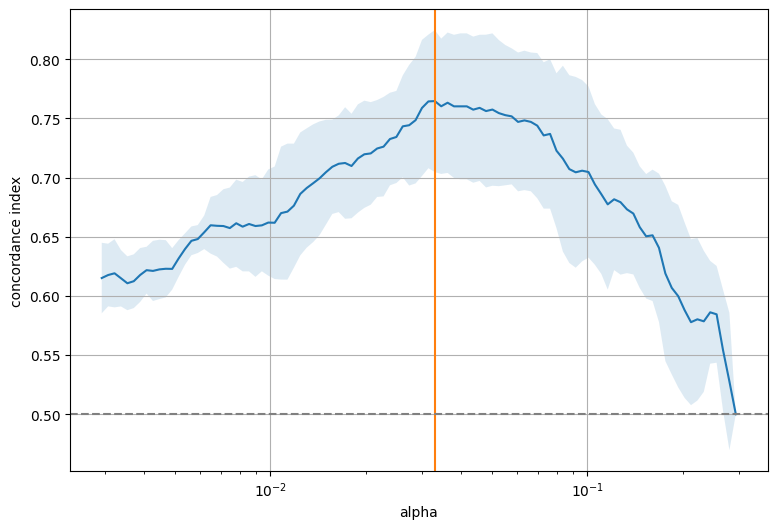

In [223]:
plot_alphas(cv_results, gcv)

Number of non-zero coefficients: 21
Best CV Concordance Index: 0.7646085594458862


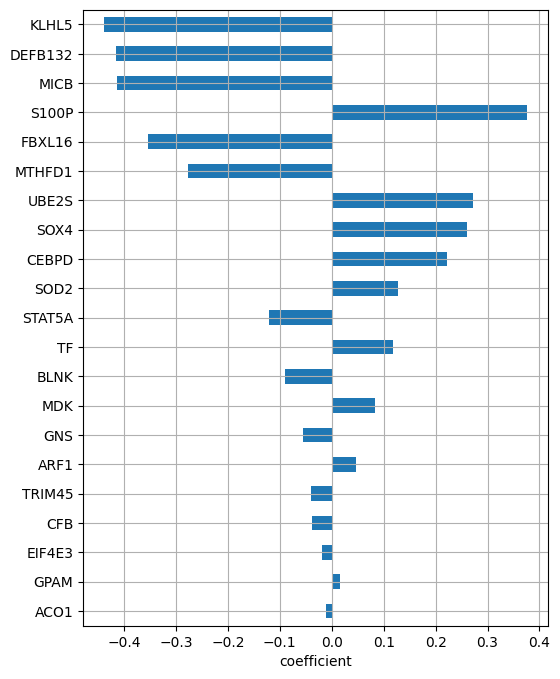

In [224]:
lasso_sig_genes, lasso_c_index = find_sig_genes(x, y, gcv)

In [225]:
check_paper_genes(lasso_sig_genes)

Found (4): ['MDK', 'S100P', 'BLNK', 'ACO1']
Missing (4): ['TSLP', 'BIRC5', 'S100B', 'RARRES3']


# Elastic Net Alpha Strength

In [226]:
estimated_alphas = get_alpha_max_min(x, y, 0.9)
cv_results, gcv = cross_validate(x, y, estimated_alphas, 0.9)

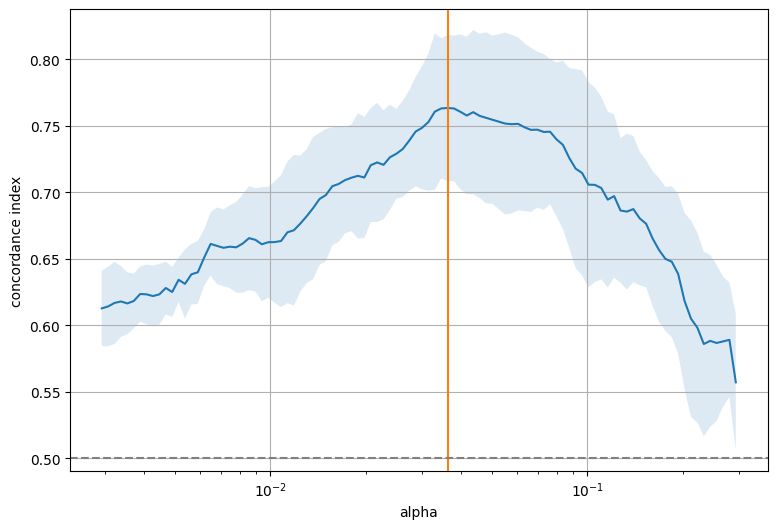

In [227]:
plot_alphas(cv_results, gcv)

Number of non-zero coefficients: 23
Best CV Concordance Index: 0.76330221729233


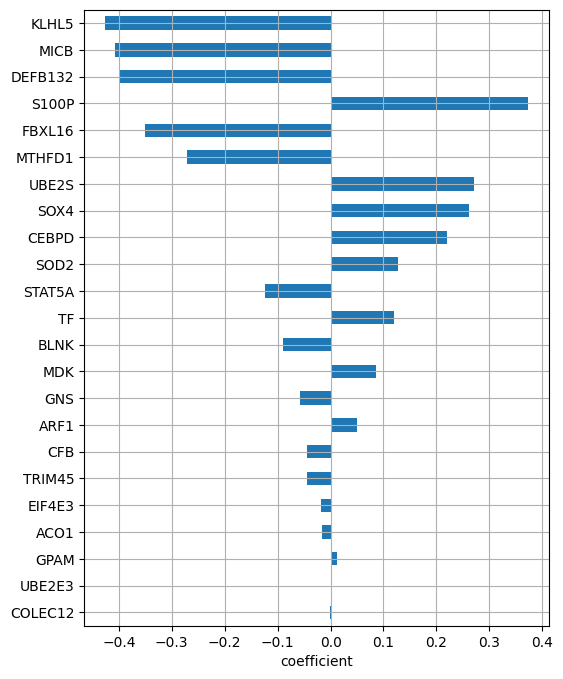

In [228]:
elastic_net_sig_genes, elastic_net_c_index = find_sig_genes(x, y, gcv)

In [229]:
best_model = lasso_sig_genes
if elastic_net_c_index > lasso_c_index:
    elastic_net_sig_genes

check_paper_genes(best_model)

Found (4): ['MDK', 'S100P', 'BLNK', 'ACO1']
Missing (4): ['TSLP', 'BIRC5', 'S100B', 'RARRES3']


In [230]:
penalized_cox_expr = filter_expr_matrix(best_model)
penalized_cox_expr.head()

,sample_name,KLHL5,BLNK,SOX4,UBE2S,S100P,DEFB132,MICB,EIF4E3,GNS,ARF1,FBXL16,CFB,SOD2,TRIM45,GPAM,MTHFD1,MDK,CEBPD,STAT5A,ACO1,TF
0,GSM1045191,6.072575,5.236619,6.020647,4.445544,5.073908,8.357489,5.413113,6.647043,8.152319,6.092818,4.139581,5.875372,9.288465,4.930487,11.131842,9.063218,5.188450,8.235638,7.981321,6.697765,6.901910
1,GSM1045192,4.181562,5.595045,6.048561,4.422642,4.521399,3.296474,6.659727,4.446082,7.004034,5.646816,4.614759,5.743448,8.606902,4.745991,5.648319,6.632947,6.270123,6.229825,7.601242,5.872591,4.818204
2,GSM1045193,5.337126,8.674915,4.799969,4.878597,4.638771,2.953570,6.921534,4.109932,4.267152,5.753160,4.833464,5.258735,4.838683,5.288228,4.731407,5.941661,5.771265,4.134739,7.501134,4.704279,4.746406
3,GSM1045194,4.675391,4.519967,7.113616,4.498002,5.977879,3.292748,5.217874,4.598521,5.922380,6.109073,4.935647,5.351327,9.178988,5.912944,5.067370,6.383969,6.423919,7.220704,7.285756,4.650540,4.738504
4,GSM1045195,6.000885,4.955369,5.754098,4.847608,4.839788,6.843711,5.132874,6.837103,7.981259,5.287706,3.937953,5.574557,10.132265,4.677008,11.344489,9.651571,5.001135,7.528966,8.350870,8.647494,7.463235


In [231]:
# ============================================================================
# Save results to CSV
# ============================================================================
penalized_cox_expr.to_csv("../datasets/csv_files/penalized_cox_sig_genes_train.csv", index=False)